In [2]:
# import necessay libraries
import pandas as pd
import numpy  as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('job.csv')
data.shape

(4596, 7)

In [4]:
data.head()

,job_title,company_name,location,start_date,ctc,experience,posted
0,Business Development Associate,Break The Code,Mumbai,Starts Immediately,"₹ 2,00,000 - 3,00,000",0-1 years,3 days ago
1,IELTS/PTE/Spoken English Trainer,DePioneer Education Overseas,Delhi,Starts Immediately,"₹ 3,00,000 - 3,50,000",0-2 years,1 week ago
2,Fashion Designer,Valkyre Clothing,Mumbai,Starts Immediately,"₹ 3,00,000 - 3,50,000",0-2 years,3 days ago\n\n\nBe an early applicant
3,Corporate Sales Executive,Kompass India Information Private Limited,Mumbai,Starts Immediately,"₹ 2,00,000 - 4,00,000",0-5 years,3 weeks ago
4,Junior Python Developer,Extension Technologies Private Limited,Faridabad,Starts Immediately,"₹ 2,40,000 - 3,60,000",0-2 years,2 weeks ago


In [5]:
data.columns

Index(['job_title', 'company_name', 'location', 'start_date', 'ctc',
       'experience', 'posted'],
      dtype='str')

In [6]:
data.isnull().sum()

job_title       0
company_name    0
location        0
start_date      0
ctc             0
experience      0
posted          0
dtype: int64

In [7]:
data['job_title'].duplicated().sum()

np.int64(2829)

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4596 entries, 0 to 4595
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   job_title     4596 non-null   str  
 1   company_name  4596 non-null   str  
 2   location      4596 non-null   str  
 3   start_date    4596 non-null   str  
 4   ctc           4596 non-null   str  
 5   experience    4596 non-null   str  
 6   posted        4596 non-null   str  
dtypes: str(7)
memory usage: 251.5 KB


In [9]:
data['ctc'].value_counts()

ctc
₹ 2,00,000 - 3,00,000      520
₹ 2,00,000                 274
₹ 2,00,000 - 2,50,000      249
₹ 2,00,000 - 2,40,000      205
Competitive salary         202
                          ... 
₹ 50,40,000 - 64,80,000      1
₹ 21,60,000 - 36,00,000      1
₹ 2,20,000 - 4,25,000        1
₹ 17,00,000 - 25,00,000      1
₹ 24,00,000 - 30,00,000      1
Name: count, Length: 487, dtype: int64

In [10]:
data['job_title'].value_counts()[:5]

job_title
Business Development Executive    290
Business Development Associate    129
Graphic Designer                  126
Sales Executive                    88
Digital Marketing Executive        73
Name: count, dtype: int64

In [11]:
data['ctc'].unique()

<StringArray>
[  '₹ 2,00,000 - 3,00,000',   '₹ 3,00,000 - 3,50,000',
   '₹ 2,00,000 - 4,00,000',   '₹ 2,40,000 - 3,60,000',
   '₹ 2,40,000 - 3,00,000',   '₹ 2,00,000 - 2,50,000',
   '₹ 2,52,000 - 4,00,000',  '₹ 7,00,000 - 10,00,000',
   '₹ 5,00,000 - 8,00,000',   '₹ 4,00,000 - 7,00,000',
 ...
 '₹ 28,80,000 - 36,00,000',  '₹ 6,60,000 - 10,80,000',
   '₹ 2,40,000 - 3,36,000',   '₹ 5,00,000 - 8,50,000',
   '₹ 4,80,000 - 9,60,000', '₹ 50,40,000 - 64,80,000',
 '₹ 21,60,000 - 36,00,000',   '₹ 2,20,000 - 4,25,000',
 '₹ 17,00,000 - 25,00,000', '₹ 24,00,000 - 30,00,000']
Length: 487, dtype: str

In [32]:
def clean_ctc(series):
    return (series
            .str.replace('₹', '', regex=False)
            .str.replace(',', '', regex=False)
            .str.strip()
           )

data['min_ctc'] = clean_ctc(data['ctc'].str.split('-').str[0])
data['max_ctc'] = clean_ctc(data['ctc'].str.split('-').str[-1])

# Optional: convert to numeric for calculations
data['min_ctc'] = pd.to_numeric(data['min_ctc'], errors='coerce')
data['max_ctc'] = pd.to_numeric(data['max_ctc'], errors='coerce')

In [12]:
data['experience'].value_counts()

experience
0-2 years      2730
0-5 years       758
1-3 years       335
0-1 years       201
4-6 years       163
0-3 years        47
7-10 years       47
1-2 years        44
1-5 years        43
2-5 years        42
3-5 years        38
0 years          37
4-5 years        19
2-4 years        16
1 year           15
1-4 years        13
0-4 years        10
2 years          10
2-3 years         9
10-15 years       8
3-4 years         3
3 years           2
4 years           1
6-10 years        1
5-7 years         1
2-10 years        1
3-6 years         1
3-7 years         1
Name: count, dtype: int64

In [38]:
data['experience'] = data['experience'].str.replace(' years', "")
data['min_exp'] = clean_ctc(data['experience'].str.split('-').str[0])
data['max_exp'] = clean_ctc(data['experience'].str.split('-').str[-1])

# Optional: convert to numeric for calculations
data['min_exp'] = pd.to_numeric(data['min_exp'], errors='coerce')
data['max_exp'] = pd.to_numeric(data['max_exp'], errors='coerce')

In [39]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4596 entries, 0 to 4595
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   job_title     4596 non-null   str    
 1   company_name  4596 non-null   str    
 2   location      4596 non-null   str    
 3   start_date    4596 non-null   str    
 4   ctc           4596 non-null   str    
 5   experience    4596 non-null   str    
 6   posted        4596 non-null   str    
 7   min_ctc       4388 non-null   float64
 8   max_ctc       4392 non-null   float64
 9   min_exp       4581 non-null   float64
 10  max_exp       4581 non-null   float64
dtypes: float64(4), str(7)
memory usage: 395.1 KB


In [60]:
data[data.isna().any(axis= 1)]

,job_title,company_name,location,start_date,ctc,experience,posted,min_ctc,max_ctc,min_exp,max_exp
13,Data Analyst,Media.net,Mumbai,Starts Immediately,"₹ 4,00,000 - 5,00,000",1 year,6 days ago,400000.0,500000.0,NaN,NaN
52,3D Generalist,Studio Image Works,Gurgaon,Starts Immediately,"₹ 3,00,000 - 5,00,000",1 year,3 weeks ago,300000.0,500000.0,NaN,NaN
282,Marketing & Sales Executive,Zigsaw Consultancy,Ludhiana,Starts Immediately,"₹ 5,00,000 - 5,10,000",1 year,4 days ago,500000.0,510000.0,NaN,NaN
325,Business Development Manager,Good Homes Kitchenware LLP,Bangalore,Starts Immediately,"₹ 5,50,000 - 6,50,000",1 year,3 days ago,550000.0,650000.0,NaN,NaN
332,Associate Recruiter,Jalan Technology Consulting,Jaipur,Starts Immediately,"₹ 2,40,000 - 3,00,000",1 year,6 days ago,240000.0,300000.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
4591,PHP Developer,Unnati,Gurgaon,Starts Immediately,Competitive salary,3-5,3 weeks ago,NaN,NaN,3.0,5.0
4592,Software Developer,Unnati,Gurgaon,Starts Immediately,Competitive salary,2-10,3 weeks ago,NaN,NaN,2.0,10.0
4593,Social Media Marketing Manager,Unnati,Delhi,Starts Immediately,Competitive salary,3-4,3 weeks ago,NaN,NaN,3.0,4.0
4594,Graphic Designer,Unnati,Gurgaon,Starts Immediately,Competitive salary,3-6,3 weeks ago,NaN,NaN,3.0,6.0


## we have "competive salary" as value in ctc which lead null in min & max ctc

In [64]:
# Extract only numeric part from "1 year", "3-5", "2-10" etc.
data['min_exp'] = data['experience'].str.extract(r'(\d+)').astype(float)
data['max_exp'] = data['experience'].str.extract(r'(\d+)-?(\d+)?')[1].fillna(data['min_exp']).astype(float)

In [65]:
data[data['ctc'] == 'Competitive salary']

,job_title,company_name,location,start_date,ctc,experience,posted,min_ctc,max_ctc,min_exp,max_exp
3989,Java Developer,Leaguesol Private Limited,Hyderabad,Starts Immediately,Competitive salary,4-6,1 day ago,NaN,NaN,4.0,6.0
3990,Java Developer,Leaguesol Private Limited,Bangalore,Starts Immediately,Competitive salary,4-6,1 day ago,NaN,NaN,4.0,6.0
3995,Accountant,Freshleaf Teas,Ludhiana,Starts Immediately,Competitive salary,0-1,1 day ago,NaN,NaN,0.0,1.0
3996,Graphic Designer,Freshleaf Teas,Ludhiana,Starts Immediately,Competitive salary,0-1,1 day ago,NaN,NaN,0.0,1.0
4008,Operations Manager,R3 Consultant,Mumbai,Starts Immediately,Competitive salary,4-6,2 days ago,NaN,NaN,4.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...
4591,PHP Developer,Unnati,Gurgaon,Starts Immediately,Competitive salary,3-5,3 weeks ago,NaN,NaN,3.0,5.0
4592,Software Developer,Unnati,Gurgaon,Starts Immediately,Competitive salary,2-10,3 weeks ago,NaN,NaN,2.0,10.0
4593,Social Media Marketing Manager,Unnati,Delhi,Starts Immediately,Competitive salary,3-4,3 weeks ago,NaN,NaN,3.0,4.0
4594,Graphic Designer,Unnati,Gurgaon,Starts Immediately,Competitive salary,3-6,3 weeks ago,NaN,NaN,3.0,6.0


In [66]:
## we can fill these "competive salary" with median
median_min = data['min_ctc'].median()
median_max = data['max_ctc'].median()

data['min_ctc'] = data['min_ctc'].fillna(median_min)
data['max_ctc'] = data['max_ctc'].fillna(median_max)

In [67]:
data.isnull().sum()

job_title       0
company_name    0
location        0
start_date      0
ctc             0
experience      0
posted          0
min_ctc         0
max_ctc         0
min_exp         0
max_exp         0
dtype: int64

In [71]:
## convert float64 into int64
data['min_ctc'] = data['min_ctc'].astype('Int64')
data['max_ctc'] = data['max_ctc'].astype('Int64')
data['min_exp'] = data['min_exp'].astype('Int64')
data['max_exp'] = data['max_exp'].astype('Int64')

In [72]:
data.describe()

,min_ctc,max_ctc,min_exp,max_exp
count,4596.0,4596.0,4596.0,4596.0
mean,294720.321584,428227.586597,0.41188,2.881419
std,237383.571774,421406.019594,1.187467,1.65727
min,200000.0,1441.0,0.0,0.0
25%,200000.0,260000.0,0.0,2.0
50%,240000.0,350000.0,0.0,2.0
75%,300000.0,500000.0,0.0,4.0
max,6000000.0,11750000.0,10.0,15.0


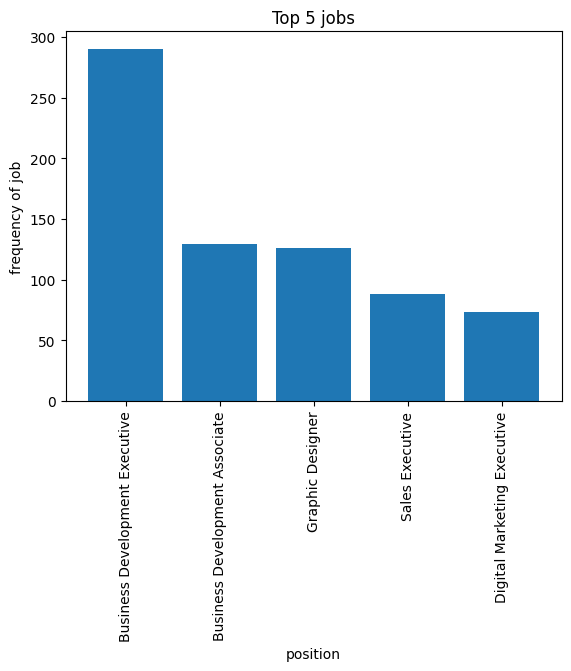

In [ ]:
top_5_jobs = data['job_title'].value_counts().head(5)

plt.bar(x = top_5_jobs.index, height= top_5_jobs.values)
plt.title("Top 5 jobs")
plt.xlabel("position")
plt.ylabel("frequency of job")
plt.xticks(rotation = 90)
plt.show()

C:\Users\Manikanth Reddy\AppData\Local\Temp\ipykernel_30700\2418113649.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5_jobs, x='job_title', y='frequency', palette='viridis')


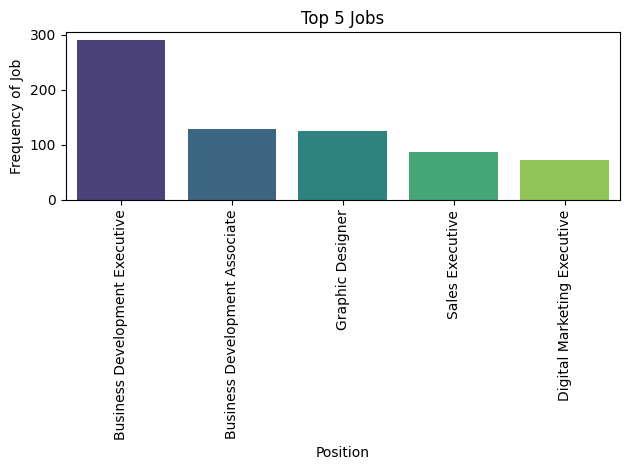

In [14]:
# instead we can use seaborn to make it more nice
import seaborn as sns

top_5_jobs = data['job_title'].value_counts().head(5).reset_index()
top_5_jobs.columns = ['job_title', 'frequency']

sns.barplot(data=top_5_jobs, x='job_title', y='frequency', palette='viridis')
plt.title("Top 5 Jobs")
plt.xlabel("Position")
plt.ylabel("Frequency of Job")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [20]:
data['posted'].unique()

<StringArray>
[                              '3 days ago',
                               '1 week ago',
    '3 days ago\n\n\nBe an early applicant',
                              '3 weeks ago',
                              '2 weeks ago',
     '1 day ago\n\n\nBe an early applicant',
                               '4 days ago',
                               '2 days ago',
                               '6 days ago',
                            'Few hours ago',
                                    'Today',
                                '1 day ago',
                               '5 days ago',
      'Just now\n\n\nBe an early applicant',
 'Few hours ago\n\n\nBe an early applicant',
         'Today\n\n\nBe an early applicant',
    '2 days ago\n\n\nBe an early applicant',
    '5 days ago\n\n\nBe an early applicant',
    '4 days ago\n\n\nBe an early applicant',
    '6 days ago\n\n\nBe an early applicant',
    '7 days ago\n\n\nBe an early applicant',
    '1 week ago\n\n\nBe an early applican

In [23]:
data['posted'] = data["posted"].str.replace("\n\n\nBe an early applicant", "")
data['posted'].unique()

<StringArray>
[   '3 days ago',    '1 week ago',   '3 weeks ago',   '2 weeks ago',
     '1 day ago',    '4 days ago',    '2 days ago',    '6 days ago',
 'Few hours ago',         'Today',    '5 days ago',      'Just now',
    '7 days ago']
Length: 13, dtype: str

In [73]:
duplicate_row_count = data.duplicated().sum()
duplicate_listing_mask = data.duplicated(subset=['job_title', 'company_name', 'location'], keep=False)
duplicate_listing_count = duplicate_listing_mask.sum()

print(f'Exact duplicate rows: {duplicate_row_count}')
print(f'Rows involved in duplicate job listings: {duplicate_listing_count}')


Exact duplicate rows: 95
Rows involved in duplicate job listings: 326


In [74]:
data[data.duplicated()].head(10)

,job_title,company_name,location,start_date,ctc,experience,posted,min_ctc,max_ctc,min_exp,max_exp
97,Business Development Executive,Plada Infotech Services Limited,"Noida, Gurgaon, Delhi",Starts Immediately,"₹ 2,00,000 - 4,00,000",0-2,1 week ago,200000,400000,0,2
483,Back Office Executive,Suprem Service,Work from home,Starts Immediately,"₹ 4,00,000 - 7,00,000",0-1,1 day ago,400000,700000,0,1
542,Business Development Associate,Break The Code,Mumbai,Starts Immediately,"₹ 2,00,000 - 3,00,000",0-1,3 days ago,200000,300000,0,1
772,Corporate Sales Executive,Kompass India Information Private Limited,Mumbai,Starts Immediately,"₹ 2,00,000 - 4,00,000",0-5,3 weeks ago,200000,400000,0,5
929,Customer Acquisition Executive,Sutra Services Private Limited,Mumbai,Starts Immediately,"₹ 2,00,000 - 3,50,000",0-2,3 weeks ago,200000,350000,0,2
942,Business Development Executive,Saroj Education Group,Delhi,Starts Immediately,"₹ 2,00,000 - 4,00,000",0-2,3 weeks ago,200000,400000,0,2
1300,Fashion Designer,Valkyre Clothing,Mumbai,Starts Immediately,"₹ 3,00,000 - 3,50,000",0-2,3 days ago,300000,350000,0,2
1341,IELTS/PTE/Spoken English Trainer,DePioneer Education Overseas,Delhi,Starts Immediately,"₹ 3,00,000 - 3,50,000",0-2,1 week ago,300000,350000,0,2
1446,Operations Executive,RoaDo,Bangalore,Starts Immediately,"₹ 2,50,000 - 3,50,000",0-2,2 days ago,250000,350000,0,2
1944,Video Editor & Graphic Designer,Brilliance Academy,Work from home,Starts Immediately,"₹ 2,40,000 - 3,00,000",0-2,1 week ago,240000,300000,0,2


In [76]:
duplicate_job_listings = (data.loc[duplicate_listing_mask]
    .sort_values(['job_title', 'company_name', 'location'])
    [['job_title', 'company_name', 'location', 'ctc', 'experience', 'posted']]
)

duplicate_job_listings.head(5)

,job_title,company_name,location,ctc,experience,posted
679,Accountant,A1 Advance,Work from home,"₹ 4,00,000 - 7,00,000",0,1 week ago
2388,Accountant,A1 Advance,Work from home,"₹ 5,00,000 - 7,00,000",0-5,1 week ago
4250,Accountant,Aline HR Consultancy,Mumbai,"₹ 2,64,000 - 3,00,000",1-3,2 weeks ago
4294,Accountant,Aline HR Consultancy,Mumbai,"₹ 2,64,000 - 3,00,000",1-3,3 weeks ago
4046,Accountant,Gamut HR Solutions,Hyderabad,"₹ 3,00,000 - 3,24,000",4-6,6 days ago
